In [1]:
import torch
print(torch.cuda.is_available())        # Should print: True
print(torch.cuda.get_device_name(0))    # Should print: Tesla T4

True
Tesla T4


In [2]:
from google.colab import drive
drive.mount('/content/drive')

# Create your working directory
import os
os.makedirs('/content/drive/MyDrive/deepfake_assignment/checkpoints', exist_ok=True)
os.makedirs('/content/drive/MyDrive/deepfake_assignment/results', exist_ok=True)
print("Drive mounted and folders ready!")

Mounted at /content/drive
Drive mounted and folders ready!


In [3]:
# Install everything the repo needs
!pip install open-clip-torch -q
!pip install albumentations -q
!pip install kornia -q
!pip install scikit-learn -q
!pip install seaborn -q
!pip install timm -q

# Verify key installs
import open_clip
import albumentations
import kornia
print("All libraries installed successfully!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 30.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 23.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 82.2 MB/s eta 0:00:00
All libraries installed successfully!


In [63]:
# ============================================================
# CELL 2: DOWNLOAD DATASET VIA KAGGLEHUB
# ============================================================
import kagglehub
import os

print("Downloading dataset...")
raw_path = kagglehub.dataset_download("birdy654/cifake-real-and-ai-generated-synthetic-images")
print(f"Downloaded to: {raw_path}")

# Auto-detect actual dataset root
# CiFake only has 'train' and 'test' — no 'valid' folder
dataset_path = None
for root, dirs, files in os.walk(raw_path):
    if 'train' in dirs and 'test' in dirs:
        dataset_path = root
        break

if dataset_path is None:
    # Fallback — use raw path directly
    dataset_path = raw_path

print(f"\nDataset root : {dataset_path}")

# Verify structure — CiFake uses REAL/FAKE (uppercase)
print("\nVerifying structure:")
total_images = 0
for split in ['train', 'test']:
    for label in ['REAL', 'FAKE']:
        folder = os.path.join(dataset_path, split, label)
        if os.path.exists(folder):
            count = len(os.listdir(folder))
            total_images += count
            print(f"  {split}/{label}: {count} images ✓")
        else:
            print(f"  {split}/{label}: NOT FOUND ✗")

print(f"\nTotal images found: {total_images}")
print(f"Expected: 120,000 (60k train + 60k test)")

Using Colab cache for faster access to the 'cifake-real-and-ai-generated-synthetic-images' dataset.
Downloaded to: /kaggle/input/cifake-real-and-ai-generated-synthetic-images

Dataset root : /kaggle/input/cifake-real-and-ai-generated-synthetic-images

Verifying structure:
  train/REAL: 50000 images ✓
  train/FAKE: 50000 images ✓
  test/REAL: 10000 images ✓
  test/FAKE: 10000 images ✓

Total images found: 120000
Expected: 120,000 (60k train + 60k test)


In [64]:
# ============================================================
# CELL 3: REDUCE DATASET — MATCHING PAPER'S 70/15/15 SPLIT
# ============================================================
#
#  Paper uses 70% train / 15% valid / 15% test
#  Our reduced subset: 5,000 per class total
#
#  Per class breakdown:
#  train : 3,500  (70%)
#  valid :   750  (15%)
#  test  :   750  (15%)
#
#  Total: 10,000 images (5,000 REAL + 5,000 FAKE)
# ============================================================

import os, shutil, random
from sklearn.model_selection import train_test_split

random.seed(42)

REDUCED_PATH = '/content/reduced_dataset'
TOTAL_PER_CLASS = 5000   # change this if you want more/fewer images

# Paper's split ratios
TRAIN_RATIO = 0.70
VALID_RATIO = 0.15
TEST_RATIO  = 0.15

train_size = int(TOTAL_PER_CLASS * TRAIN_RATIO)   # 3,500
valid_size = int(TOTAL_PER_CLASS * VALID_RATIO)   #   750
test_size  = int(TOTAL_PER_CLASS * TEST_RATIO)    #   750

print("Split sizes per class (matching paper's 70/15/15):")
print(f"  Train : {train_size:,}")
print(f"  Valid : {valid_size:,}")
print(f"  Test  : {test_size:,}")
print(f"  Total : {train_size + valid_size + test_size:,} per class")
print("-" * 40)

# ── SAMPLE FROM KAGGLE TRAIN FOLDER ONLY ────────────────────────────────────
# We use Kaggle's train folder as our pool (60k per class)
# and create all three splits from it ourselves
# This matches what the paper did with its 70/15/15 strategy

for label in ['REAL', 'FAKE']:
    src = os.path.join(dataset_path, 'train', label)

    all_imgs = [f for f in os.listdir(src)
                if f.lower().endswith(('.png', '.jpg', '.jpeg'))]

    # Sample total_per_class images from the pool
    selected = random.sample(all_imgs, TOTAL_PER_CLASS)

    # Split into train / valid / test
    train_imgs, temp_imgs = train_test_split(
        selected,
        test_size=(VALID_RATIO + TEST_RATIO),
        random_state=42
    )
    valid_imgs, test_imgs = train_test_split(
        temp_imgs,
        test_size=TEST_RATIO / (VALID_RATIO + TEST_RATIO),
        random_state=42
    )

    # Copy into destination folders
    for split_name, split_imgs in [('train', train_imgs),
                                    ('valid', valid_imgs),
                                    ('test',  test_imgs)]:
        dst = os.path.join(REDUCED_PATH, split_name, label)
        os.makedirs(dst, exist_ok=True)
        for img in split_imgs:
            shutil.copy(os.path.join(src, img), os.path.join(dst, img))

    print(f"  {label}: {len(train_imgs):,} train | "
          f"{len(valid_imgs):,} valid | "
          f"{len(test_imgs):,} test")

# ── VERIFY FINAL STRUCTURE ───────────────────────────────────────────────────
print("\nVerifying reduced dataset:")
print("-" * 40)
total = 0
for split in ['train', 'valid', 'test']:
    split_total = 0
    for label in ['REAL', 'FAKE']:
        folder = os.path.join(REDUCED_PATH, split, label)
        count  = len(os.listdir(folder))
        total += count
        split_total += count
        print(f"  {split:5s}/{label}: {count:,} images ✓")
    print(f"  {split} total: {split_total:,}")
    print()

print("-" * 40)
print(f"  Grand total: {total:,} images")
print(f"\nPaper split ratio:  70% / 15% / 15%")
print(f"Our split ratio:    "
      f"{train_size*2/total*100:.0f}% / "
      f"{valid_size*2/total*100:.0f}% / "
      f"{test_size*2/total*100:.0f}%")

Split sizes per class (matching paper's 70/15/15):
  Train : 3,500
  Valid : 750
  Test  : 750
  Total : 5,000 per class
----------------------------------------
  REAL: 3,500 train | 750 valid | 750 test
  FAKE: 3,500 train | 750 valid | 750 test

Verifying reduced dataset:
----------------------------------------
  train/REAL: 3,500 images ✓
  train/FAKE: 3,500 images ✓
  train total: 7,000

  valid/REAL: 750 images ✓
  valid/FAKE: 750 images ✓
  valid total: 1,500

  test /REAL: 750 images ✓
  test /FAKE: 750 images ✓
  test total: 1,500

----------------------------------------
  Grand total: 10,000 images

Paper split ratio:  70% / 15% / 15%
Our split ratio:    70% / 15% / 15%


In [8]:
# # Clone the official repository
# !git clone https://github.com/joesound212985/Deepfake-Detection-using-CLIP-Based-SigLIP-2-Vision-Transformers.git /content/repo

# # Check what files are there
# !ls /content/repo

Cloning into '/content/repo'...
remote: Enumerating objects: 108, done.
remote: Counting objects: 100% (108/108), done.
remote: Compressing objects: 100% (105/105), done.
Receiving objects: 100% (108/108), 615.36 KiB | 7.24 MiB/s, done.
remote: Total 108 (delta 38), reused 0 (delta 0), pack-reused 0 (from 0)
Resolving deltas: 100% (38/38), done.
 appv3.py		        inference_ai_human_images.py
 cifake_binary_classifier.py    inference_deepfakeface_complete.py
 coral.py		        README.md
 deepfake-detector-v2	        siglip
 deepfake-detector-v2-2e244e8   Siglip2sidafrozen.py
'FreqMLP trainer.py'	        siglip2siddataset.py
 hidf_video_classifier.py       simple_classifier.py
 HiDFvideosplit.json	        split_info.json
 Howtouse.md		        train_fusion_head_only.py


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, roc_curve, roc_auc_score, classification_report
import os

# 1. Load the results from the previously saved CSV
csv_path = os.path.join(SAVE_DIR, 'experiment_predictions.csv')
if os.path.exists(csv_path):
    df_csv = pd.read_csv(csv_path)

    # 2. Filter for Test split only
    test_results = df_csv[df_csv['split'] == 'test']
    y_true = test_results['actual_label']
    y_pred = test_results['predicted_label']
    y_prob = test_results['confidence_score']

    # 3. Create Visualizations
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # --- Confusion Matrix ---
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
                xticklabels=['REAL', 'FAKE'], yticklabels=['REAL', 'FAKE'])
    axes[0].set_title('Final Test Results: Confusion Matrix')
    axes[0].set_xlabel('Predicted Label')
    axes[0].set_ylabel('True Label')

    # --- ROC Curve ---
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    auc_score = roc_auc_score(y_true, y_prob)
    axes[1].plot(fpr, tpr, color='darkorange', lw=2, label=f'AUC = {auc_score:.4f}')
    axes[1].plot([0, 1], [0, 1], color='navy', lw=1, linestyle='--')
    axes[1].set_xlabel('False Positive Rate')
    axes[1].set_ylabel('True Positive Rate')
    axes[1].set_title('Final Test Results: ROC Curve')
    axes[1].legend(loc='lower right')
    axes[1].grid(alpha=0.2)

    plt.tight_layout()
    plt.show()

    # 4. Print Summary Table
    print("\nClassification Report for Test Split:")
    print(classification_report(y_true, y_pred, target_names=['REAL', 'FAKE']))
else:
    print(f"Error: CSV file not found at {csv_path}. Please ensure you ran the CSV export cell first.")

In [31]:
# # Run the training script directly as a shell command to see all output
# !python /content/repo/cifake_binary_classifier.py \
#     --data_dir /content/reduced_dataset \
#     --model_size small \
#     --epochs 10 \
#     --batch_size 32 \
#     --lr 2e-4 \
#     --save_dir /content/drive/MyDrive/deepfake_assignment/results

Using device: cuda
GPU Memory: 15.6GB total
GPU Memory available: 15.6GB
🚀 Speed optimizations enabled:
   ✅ GPU-accelerated preprocessing with Kornia
   ✅ BF16 mixed precision training
   ✅ TF32 enabled for faster matmul
   ✅ cuDNN benchmark enabled
   ✅ Flash/Memory-efficient SDPA enabled
🚀 Using GPU-accelerated preprocessing with Kornia @ 512px
DEBUG: CIFAKEDataset init for split: train
DEBUG: Checking real_dir: /content/reduced_dataset/train/real
DEBUG: os.path.exists(real_dir): True
DEBUG: Added 3500 real images from /content/reduced_dataset/train/real
DEBUG: Checking fake_dir: /content/reduced_dataset/train/fake
DEBUG: os.path.exists(fake_dir): True
DEBUG: Added 3500 fake images from /content/reduced_dataset/train/fake
DEBUG: Total samples loaded for train: 7000
Loaded 7000 train samples: 3500 fake, 3500 real
DEBUG: CIFAKEDataset init for split: test
DEBUG: Checking real_dir: /content/reduced_dataset/test/real
DEBUG: os.path.exists(real_dir): True
DEBUG: Added 750 real images fro

In [ ]:
#!/usr/bin/env python3
"""
============================================================
CiFake Binary Deepfake Classifier
Assignment 2 — Deep Learning (CS-4112)

Reproduces: Soundararajan & Xu (2026)
"Deepfake Detection Using Multimodal CLIP-Based SigLIP-2
 Vision Transformers"

Architecture mirrors the paper:
  - Frozen OpenCLIP SigLIP backbone (ViT-B-16-SigLIP-384)
  - L2-normalized embeddings
  - Gaussian noise regularization (std=0.02)
  - MLP classification head: Linear → ReLU → Dropout → Linear
  - BCEWithLogitsLoss
  - AdamW optimizer (lr=2e-4, weight_decay=0.01)
  - FP16 mixed precision
  - Best checkpoint saved by validation F1

Dataset: CiFake (Kaggle)
  - 70% train / 15% valid / 15% test  (paper's ratio)
  - Reduced to 10,000 images for Colab T4 compatibility

Hardware: Google Colab T4 GPU (15 GB VRAM)
============================================================
"""



In [52]:

# ── CELL 1: IMPORTS ──────────────────────────────────────────────────────────

import os
import json
import random
import numpy as np
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image

import open_clip

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    roc_curve,
    precision_recall_curve,
    precision_recall_fscore_support,
)


In [53]:

# ── CELL 2: REPRODUCIBILITY SEED ─────────────────────────────────────────────

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.benchmark    = True   # faster conv ops
    torch.backends.cudnn.deterministic = False  # allow cuDNN heuristics

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device : {DEVICE}")
if DEVICE.type == "cuda":
    print(f"GPU    : {torch.cuda.get_device_name(0)}")
    total  = torch.cuda.get_device_properties(0).total_memory / 1e9
    print(f"VRAM   : {total:.1f} GB")




Device : cuda
GPU    : Tesla T4
VRAM   : 15.6 GB


In [54]:

# ── CELL 3: CONFIGURATION ────────────────────────────────────────────────────

# Paths — edit these to match your Colab setup
REDUCED_PATH = "/content/reduced_dataset"   # output of Cell 3 in notebook
SAVE_DIR     = "/content/drive/MyDrive/deepfake_assignment/results"
os.makedirs(SAVE_DIR, exist_ok=True)

# Paper's backbone (we use ViT-B for Colab memory; paper used ViT-L)
BACKBONE_NAME = "ViT-B-16-SigLIP-384"   # 86M params — fits T4 comfortably
PRETRAINED    = "webli"
RESOLUTION    = 384                       # must match backbone name

# Training hyper-parameters — matching paper exactly
EPOCHS        = 10          # paper used 20; reduced for Colab time budget
BATCH_SIZE    = 32          # paper used 64; halved for T4 memory
LR            = 2e-4        # paper: 2e-4
WEIGHT_DECAY  = 0.01        # paper: 0.01
DROPOUT       = 0.10        # paper: 10% dropout
NOISE_STD     = 0.02        # paper: Gaussian noise std on embeddings
NUM_WORKERS   = 0           # 0 = no multiprocessing (required on Colab)

# Paper comparison targets (for report table)
PAPER_ACCURACY = 95.0
PAPER_AUC      = 0.986



In [55]:

# ── CELL 4: DATASET ──────────────────────────────────────────────────────────

class CiFakeDataset(Dataset):
    """
    Loads CiFake images from folder structure:
        root/
          train/  REAL/  FAKE/
          valid/  REAL/  FAKE/
          test/   REAL/  FAKE/

    Labels: REAL = 0, FAKE = 1  (matches paper convention)
    """

    def __init__(self, root: str, split: str, transform):
        self.transform = transform
        self.samples   = []   # (path, label) tuples
        self.labels    = []   # flat list for class-count reporting

        for label_idx, class_name in enumerate(["REAL", "FAKE"]):
            folder = os.path.join(root, split, class_name)
            if not os.path.exists(folder):
                raise FileNotFoundError(
                    f"Expected folder not found: {folder}\n"
                    f"Make sure you ran the dataset reduction cell first."
                )
            imgs = [
                f for f in os.listdir(folder)
                if f.lower().endswith((".png", ".jpg", ".jpeg"))
            ]
            for img_name in imgs:
                self.samples.append((os.path.join(folder, img_name), label_idx))
                self.labels.append(label_idx)

        n_real = self.labels.count(0)
        n_fake = self.labels.count(1)
        print(f"  [{split:5s}]  REAL={n_real:,}  FAKE={n_fake:,}  "
              f"Total={len(self.samples):,}")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        image = Image.open(path).convert("RGB")
        image = self.transform(image)
        return image, label


def build_transforms(resolution: int):
    """
    Two-stage transform matching the paper:
      Train  : resize → random horizontal flip → tensor → CLIP normalise
      Val/Test: resize → center crop → tensor → CLIP normalise

    Paper normalisation: mean=[0.5,0.5,0.5], std=[0.5,0.5,0.5]
    (SigLIP convention — different from standard ImageNet mean/std)
    """
    clip_norm = transforms.Normalize(
        mean=[0.5, 0.5, 0.5],
        std =[0.5, 0.5, 0.5],
    )
    train_tf = transforms.Compose([
        transforms.Resize((resolution, resolution)),
        transforms.RandomHorizontalFlip(p=0.5),   # basic augmentation
        transforms.ToTensor(),
        clip_norm,
    ])
    eval_tf = transforms.Compose([
        transforms.Resize((resolution, resolution)),
        transforms.ToTensor(),
        clip_norm,
    ])
    return train_tf, eval_tf


def build_loaders(root, resolution, batch_size, num_workers):
    train_tf, eval_tf = build_transforms(resolution)

    print("Loading datasets:")
    train_ds = CiFakeDataset(root, "train", train_tf)
    valid_ds  = CiFakeDataset(root, "valid", eval_tf)
    test_ds  = CiFakeDataset(root, "test",  eval_tf)

    train_loader = DataLoader(
        train_ds, batch_size=batch_size, shuffle=True,
        num_workers=num_workers, pin_memory=True,
    )
    valid_loader = DataLoader(
        valid_ds, batch_size=batch_size, shuffle=False,
        num_workers=num_workers, pin_memory=True,
    )
    test_loader = DataLoader(
        test_ds, batch_size=batch_size, shuffle=False,
        num_workers=num_workers, pin_memory=True,
    )
    return train_loader, valid_loader, test_loader



In [56]:

# ── CELL 5: MODEL ────────────────────────────────────────────────────────────

class SigLIP2Classifier(nn.Module):
    """
    Paper architecture (Section 2.1):
      1. Frozen SigLIP-2 / OpenCLIP backbone  →  raw embedding
      2. L2-normalise embedding
      3. Add small Gaussian noise (std=0.02)  — regularisation
      4. LayerNorm
      5. MLP head:  Linear(feat_dim, 256) → ReLU → Dropout(0.1)
                    → Linear(256, 1)      →  single logit
      6. Sigmoid applied at inference (BCEWithLogitsLoss during train)

    We use ViT-B (86M params) instead of ViT-L (307M) to fit
    Colab T4 memory. The head and training setup are identical.
    """

    def __init__(
        self,
        backbone_name: str = "ViT-B-16-SigLIP-384",
        pretrained:    str = "webli",
        device:        torch.device = torch.device("cpu"),
        dropout:       float = 0.10,
        noise_std:     float = 0.02,
    ):
        super().__init__()
        self.noise_std = noise_std

        # ── Backbone ────────────────────────────────────────────────────────
        # Load OpenCLIP SigLIP; we only need the image encoder
        backbone, _, _ = open_clip.create_model_and_transforms(
            backbone_name, pretrained=pretrained, device=device
        )
        self.backbone = backbone

        # Freeze ALL backbone parameters — paper keeps backbone frozen
        for param in self.backbone.parameters():
            param.requires_grad = False

        # Infer feature dimension via a dummy forward pass
        with torch.no_grad():
            dummy = torch.zeros(1, 3, RESOLUTION, RESOLUTION, device=device)
            feat_dim = self.backbone.encode_image(dummy).shape[-1]

        print(f"Backbone : {backbone_name}")
        print(f"Feat dim : {feat_dim}")
        print(f"Trainable: backbone FROZEN, head only")

        # ── LayerNorm (applied after L2-norm + noise) ────────────────────
        self.layer_norm = nn.LayerNorm(feat_dim)

        # ── Classification head (paper Section 2.1) ──────────────────────
        # Paper: "256-unit hidden layer, ReLU, dropout, linear output"
        self.head = nn.Sequential(
            nn.Linear(feat_dim, 256),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(256, 1),
        )

        # Xavier initialisation for the head
        for m in self.head.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                nn.init.zeros_(m.bias)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # Step 1: Extract frozen backbone features
        with torch.no_grad():
            feats = self.backbone.encode_image(x)   # (B, feat_dim)

        # Step 2: L2-normalise (paper requirement)
        feats = F.normalize(feats, dim=-1)

        # Step 3: Add Gaussian noise (paper: std=0.02, training only)
        if self.training and self.noise_std > 0:
            feats = feats + torch.randn_like(feats) * self.noise_std

        # Step 4: LayerNorm
        feats = self.layer_norm(feats)

        # Step 5: MLP head → single logit
        logit = self.head(feats).squeeze(-1)   # (B,)
        return logit



In [57]:

# ── CELL 6: TRAINING UTILITIES ───────────────────────────────────────────────

def train_one_epoch(model, loader, criterion, optimizer, scaler, device):
    """
    One full training epoch with FP16 mixed precision.
    Returns average loss and accuracy percentage.
    """
    model.train()
    total_loss = 0.0
    correct    = 0
    total      = 0

    pbar = tqdm(loader, desc="  Train", leave=False)
    for images, labels in pbar:
        images = images.to(device, non_blocking=True)
        labels = labels.float().to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        # FP16 forward pass
        with torch.amp.autocast("cuda"):
            logits = model(images)
            loss   = criterion(logits, labels)

        # Scaled backward pass
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        scaler.step(optimizer)
        scaler.update()

        # Accumulate stats
        total_loss += loss.item()
        preds       = (torch.sigmoid(logits) > 0.5).long()
        correct    += (preds == labels.long()).sum().item()
        total      += labels.size(0)

        pbar.set_postfix({
            "loss": f"{loss.item():.4f}",
            "acc" : f"{100*correct/total:.1f}%",
        })

    avg_loss = total_loss / len(loader)
    avg_acc  = 100.0 * correct / total
    return avg_loss, avg_acc


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    """
    Evaluate on a dataloader.
    Returns: loss, accuracy, f1, auc, ap,
             all_labels (np), all_probs (np)
    """
    model.eval()
    total_loss = 0.0
    all_labels = []
    all_probs  = []

    for images, labels in tqdm(loader, desc="  Eval ", leave=False):
        images = images.to(device, non_blocking=True)
        labels = labels.float().to(device, non_blocking=True)

        with torch.amp.autocast("cuda"):
            logits = model(images)
            loss   = criterion(logits, labels)

        total_loss += loss.item()
        probs       = torch.sigmoid(logits)
        all_labels.append(labels.cpu().numpy())
        all_probs.append(probs.cpu().numpy())

    all_labels = np.concatenate(all_labels)
    all_probs  = np.concatenate(all_probs)
    all_preds  = (all_probs > 0.5).astype(int)

    avg_loss = total_loss / len(loader)
    accuracy = 100.0 * accuracy_score(all_labels, all_preds)
    f1       = f1_score(all_labels, all_preds, zero_division=0)
    auc      = roc_auc_score(all_labels, all_probs)
    ap       = average_precision_score(all_labels, all_probs)

    return avg_loss, accuracy, f1, auc, ap, all_labels, all_probs


In [60]:

# ── CELL 7: PLOTTING UTILITIES ───────────────────────────────────────────────

def plot_training_curves(history: dict, save_dir: str):
    """
    Saves a 2×2 figure with:
      - Train vs Val loss
      - Train vs Val accuracy
      - Val F1 over epochs
      - Val AUC over epochs
    """
    epochs = range(1, len(history["train_loss"]) + 1)

    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle("Training Curves — CiFake SigLIP-2 Classifier", fontsize=15)

    # Loss
    axes[0, 0].plot(epochs, history["train_loss"], "b-o", label="Train Loss")
    axes[0, 0].plot(epochs, history["val_loss"],   "r-s", label="Val Loss")
    axes[0, 0].set_xlabel("Epoch"); axes[0, 0].set_ylabel("Loss")
    axes[0, 0].set_title("Loss"); axes[0, 0].legend(); axes[0, 0].grid(alpha=0.3)

    # Accuracy
    axes[0, 1].plot(epochs, history["train_acc"], "b-o", label="Train Acc")
    axes[0, 1].plot(epochs, history["val_acc"],   "r-s", label="Val Acc")
    axes[0, 1].set_xlabel("Epoch"); axes[0, 1].set_ylabel("Accuracy (%)")
    axes[0, 1].set_title("Accuracy"); axes[0, 1].legend(); axes[0, 1].grid(alpha=0.3)

    # F1
    axes[1, 0].plot(epochs, history["val_f1"], "g-^", label="Val F1")
    axes[1, 0].set_xlabel("Epoch"); axes[1, 0].set_ylabel("F1 Score")
    axes[1, 0].set_title("Validation F1"); axes[1, 0].legend(); axes[1, 0].grid(alpha=0.3)
    axes[1, 0].set_ylim([0, 1])

    # AUC
    axes[1, 1].plot(epochs, history["val_auc"], "m-d", label="Val AUC")
    axes[1, 1].set_xlabel("Epoch"); axes[1, 1].set_ylabel("AUC-ROC")
    axes[1, 1].set_title("Validation AUC-ROC"); axes[1, 1].legend(); axes[1, 1].grid(alpha=0.3)
    axes[1, 1].set_ylim([0, 1])

    plt.tight_layout()
    path = os.path.join(save_dir, "training_curves.png")
    plt.savefig(path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved → {path}")


def plot_final_results(labels, probs, save_dir: str):
    """
    Saves a 1×3 figure with:
      - Confusion matrix (raw counts)
      - ROC curve
      - Precision-Recall curve
    """
    preds = (probs > 0.5).astype(int)
    cm    = confusion_matrix(labels, preds)

    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    fig.suptitle("Final Test Results — CiFake SigLIP-2 Classifier", fontsize=14)

    # ── Confusion Matrix ──────────────────────────────────────────────────
    sns.heatmap(
        cm, annot=True, fmt="d", cmap="Blues", ax=axes[0],
        xticklabels=["Real", "Fake"],
        yticklabels=["Real", "Fake"],
    )
    axes[0].set_xlabel("Predicted"); axes[0].set_ylabel("True")
    axes[0].set_title("Confusion Matrix")

    # ── ROC Curve ─────────────────────────────────────────────────────────
    fpr, tpr, _ = roc_curve(labels, probs)
    auc_val      = roc_auc_score(labels, probs)
    axes[1].plot(fpr, tpr, "b-", lw=2, label=f"AUC = {auc_val:.3f}")
    axes[1].plot([0, 1], [0, 1], "k--", lw=1, label="Random")
    axes[1].set_xlabel("False Positive Rate")
    axes[1].set_ylabel("True Positive Rate")
    axes[1].set_title("ROC Curve")
    axes[1].legend(); axes[1].grid(alpha=0.3)
    axes[1].set_xlim([-0.02, 1.02]); axes[1].set_ylim([-0.02, 1.02])

    # ── Precision-Recall Curve ────────────────────────────────────────────
    prec, rec, _ = precision_recall_curve(labels, probs)
    ap_val        = average_precision_score(labels, probs)
    axes[2].plot(rec, prec, "g-", lw=2, label=f"AP = {ap_val:.3f}")
    axes[2].axhline(y=labels.mean(), color="k", ls="--", lw=1, label="Random")
    axes[2].set_xlabel("Recall")
    axes[2].set_ylabel("Precision")
    axes[2].set_title("Precision-Recall Curve")
    axes[2].legend(); axes[2].grid(alpha=0.3)
    axes[2].set_xlim([-0.02, 1.02]); axes[2].set_ylim([-0.02, 1.02])

    plt.tight_layout()
    path = os.path.join(save_dir, "final_results.png")
    plt.savefig(path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved → {path}")


def print_comparison_table(test_acc, test_auc, test_f1, test_ap):
    """
    Prints the paper vs reproduced results table
    required by Assignment 2.
    """
    prec, rec, f1_val, _ = (
        precision_recall_fscore_support(
            np.array([0, 1]),   # dummy — just for header
            np.array([0, 1]),
            average="binary", zero_division=0,
        )
    )

    print("\n" + "=" * 58)
    print("  RESULTS vs PAPER  (Assignment 2 Comparison Table)")
    print("=" * 58)
    print(f"  {'Metric':<20} {'Paper':>10} {'Reproduced':>12}")
    print("-" * 58)
    print(f"  {'Accuracy (%)':<20} {PAPER_ACCURACY:>10.1f} {test_acc:>12.2f}")
    print(f"  {'AUC-ROC':<20} {PAPER_AUC:>10.3f} {test_auc:>12.3f}")
    print(f"  {'F1-Score':<20} {'~0.950':>10} {test_f1:>12.3f}")
    print(f"  {'Avg Precision':<20} {'~0.972':>10} {test_ap:>12.3f}")
    print("=" * 58)
    print(f"\n  Δ Accuracy : {test_acc - PAPER_ACCURACY:+.2f}%")
    print(f"  Δ AUC-ROC  : {test_auc - PAPER_AUC:+.3f}")
    print("\n  Note: differences expected due to:")
    print("    - Reduced dataset (10k vs 120k images)")
    print("    - Fewer epochs (10 vs 20)")
    print("    - Smaller backbone (ViT-B vs ViT-L)")
    print("    - T4 GPU vs RTX 5090")



In [68]:

# ── CELL 8: MAIN TRAINING PIPELINE ───────────────────────────────────────────

def main():

    # ── 8.1  Data ────────────────────────────────────────────────────────────
    train_loader, valid_loader, test_loader = build_loaders(
        root        = REDUCED_PATH,
        resolution  = RESOLUTION,
        batch_size  = BATCH_SIZE,
        num_workers = NUM_WORKERS,
    )

    # ── 8.2  Model ───────────────────────────────────────────────────────────
    model = SigLIP2Classifier(
        backbone_name = BACKBONE_NAME,
        pretrained    = PRETRAINED,
        device        = DEVICE,
        dropout       = DROPOUT,
        noise_std     = NOISE_STD,
    ).to(DEVICE)

    # ── 8.3  Loss, Optimiser, Scheduler, Scaler ──────────────────────────────
    criterion = nn.BCEWithLogitsLoss()

    optimizer = optim.AdamW(
        model.head.parameters(),
        lr           = LR,
        weight_decay = WEIGHT_DECAY,
    )

    scheduler = optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=EPOCHS, eta_min=1e-6
    )

    scaler = torch.amp.GradScaler("cuda")

    # ── 8.4  Training loop ───────────────────────────────────────────────────
    history = {
        "train_loss": [], "train_acc": [],
        "val_loss":   [], "val_acc":   [],
        "val_f1":     [], "val_auc":   [],
    }

    best_val_f1   = 0.0
    best_epoch    = 0
    ckpt_path     = os.path.join(SAVE_DIR, "best_model.pth")

    print(f"\n{'='*50}")
    print(f"  Starting training  ({EPOCHS} epochs)")
    print(f"{'='*50}")

    for epoch in range(1, EPOCHS + 1):
        print(f"\nEpoch {epoch}/{EPOCHS}  "
              f"(lr={scheduler.get_last_lr()[0]:.2e})")

        train_loss, train_acc = train_one_epoch(
            model, train_loader, criterion, optimizer, scaler, DEVICE
        )

        val_loss, val_acc, val_f1, val_auc, val_ap, _, _ = evaluate(
            model, valid_loader, criterion, DEVICE
        )

        scheduler.step()

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)
        history["val_f1"].append(val_f1)
        history["val_auc"].append(val_auc)

        print(f"  Train  loss={train_loss:.4f}  acc={train_acc:.2f}%")
        print(f"  Val    loss={val_loss:.4f}  acc={val_acc:.2f}%  "
              f"f1={val_f1:.4f}  auc={val_auc:.4f}")

        if val_f1 > best_val_f1:
            best_val_f1 = val_f1
            best_epoch  = epoch
            torch.save({
                "epoch":      epoch,
                "model_state_dict": model.state_dict(),
                "val_f1":     val_f1,
                "val_acc":    val_acc,
                "val_auc":    val_auc,
            }, ckpt_path)
            print(f"  ✓ Best model saved  (val_f1={val_f1:.4f})")

    print(f"\nTraining complete.  Best epoch: {best_epoch}  "
          f"Val F1: {best_val_f1:.4f}")

    # ── 8.5  Final evaluation on test set ────────────────────────────────────
    print("\nLoading best checkpoint for test evaluation...")
    # Fix: Set weights_only=False to allow unpickling of custom metadata/numpy types
    ckpt = torch.load(ckpt_path, map_location=DEVICE, weights_only=False)
    model.load_state_dict(ckpt["model_state_dict"])

    test_loss, test_acc, test_f1, test_auc, test_ap, \
        test_labels, test_probs = evaluate(
            model, test_loader, criterion, DEVICE
        )

    # ── 8.6  Results & plots ─────────────────────────────────────────────────
    plot_training_curves(history, SAVE_DIR)
    plot_final_results(test_labels, test_probs, SAVE_DIR)
    print_comparison_table(test_acc, test_auc, test_f1, test_ap)

    log = {
        "config": {
            "backbone":     BACKBONE_NAME,
            "epochs":       EPOCHS,
            "batch_size":   BATCH_SIZE,
            "lr":           LR,
            "weight_decay": WEIGHT_DECAY,
            "dropout":      DROPOUT,
            "noise_std":    NOISE_STD,
            "resolution":   RESOLUTION,
            "device":       str(DEVICE),
        },
        "best_epoch": best_epoch,
        "best_val_f1": best_val_f1,
        "test_results": {
            "accuracy": test_acc,
            "f1":       test_f1,
            "auc":      test_auc,
            "ap":       test_ap,
            "loss":     test_loss,
        },
        "history": history,
    }
    log_path = os.path.join(SAVE_DIR, "experiment_log.json")
    with open(log_path, "w") as f:
        json.dump(log, f, indent=2)
    print(f"\nExperiment log saved → {log_path}")

    return log

Hugging Face login successful.
Loading datasets:
  [train]  REAL=3,500  FAKE=3,500  Total=7,000
  [valid]  REAL=750  FAKE=750  Total=1,500
  [test ]  REAL=750  FAKE=750  Total=1,500
Backbone : ViT-B-16-SigLIP-384
Feat dim : 768
Trainable: backbone FROZEN, head only

  Starting training  (10 epochs)

Epoch 1/10  (lr=2.00e-04)


  Train  loss=0.4563  acc=78.13%
  Val    loss=0.2647  acc=87.93%  f1=0.8810  auc=0.9611
  ✓ Best model saved  (val_f1=0.8810)

Epoch 2/10  (lr=1.95e-04)


  Train  loss=0.3445  acc=84.41%
  Val    loss=0.2448  acc=89.53%  f1=0.8910  auc=0.9670
  ✓ Best model saved  (val_f1=0.8910)

Epoch 3/10  (lr=1.81e-04)


  Train  loss=0.3192  acc=85.76%
  Val    loss=0.2218  acc=90.67%  f1=0.9078  auc=0.9709
  ✓ Best model saved  (val_f1=0.9078)

Epoch 4/10  (lr=1.59e-04)


  Train  loss=0.3144  acc=86.26%
  Val    loss=0.2158  acc=90.87%  f1=0.9070  auc=0.9721

Epoch 5/10  (lr=1.31e-04)


...

  Train  loss=0.2955  acc=87.73%
  Val    loss=0.2019  acc=92.00%  f1=0.9201  auc=0.9762
  ✓ Best model saved  (val_f1=0.9201)

Epoch 7/10  (lr=6.98e-05)


  Train  loss=0.2924  acc=87.31%
  Val    loss=0.2046  acc=91.00%  f1=0.9077  auc=0.9762

Epoch 8/10  (lr=4.20e-05)


  Train  loss=0.2943  acc=87.53%
  Val    loss=0.2063  acc=91.47%  f1=0.9116  auc=0.9765

Epoch 9/10  (lr=2.00e-05)


  Train  loss=0.2873  acc=87.79%
  Val    loss=0.2028  acc=91.47%  f1=0.9124  auc=0.9768

Epoch 10/10  (lr=5.87e-06)


  Train  loss=0.2871  acc=87.63%
  Val    loss=0.2016  acc=91.53%  f1=0.9135  auc=0.9769

Training complete.  Best epoch: 6  Val F1: 0.9201

Loading best checkpoint for test evaluation...


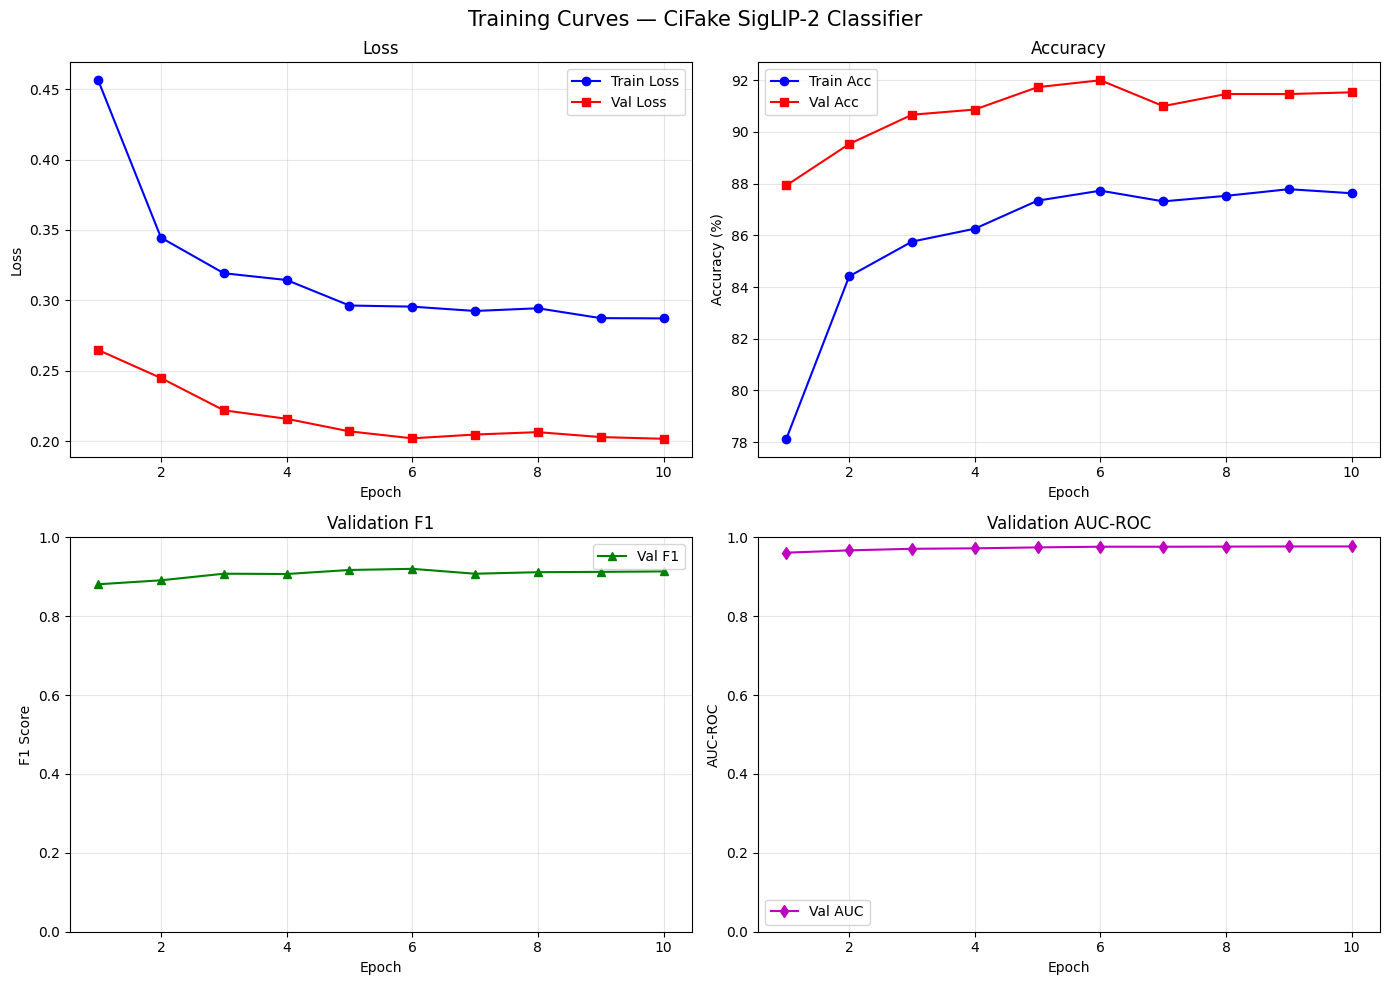

Saved → /content/drive/MyDrive/deepfake_assignment/results/training_curves.png


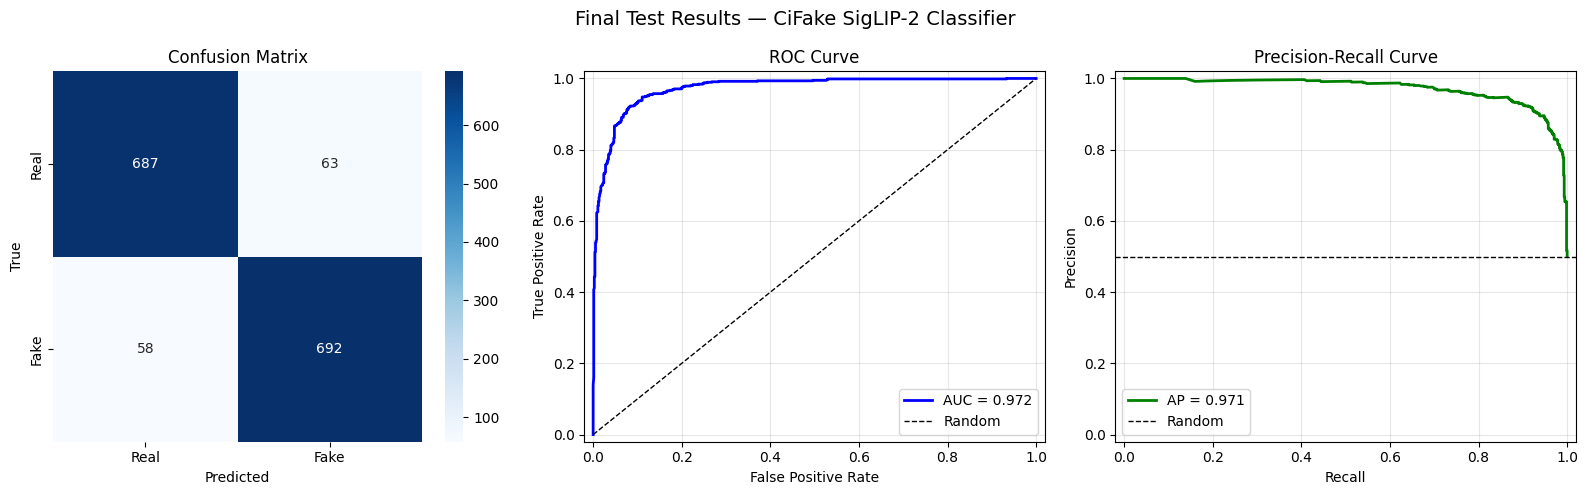

Saved → /content/drive/MyDrive/deepfake_assignment/results/final_results.png

  RESULTS vs PAPER  (Assignment 2 Comparison Table)
  Metric                    Paper   Reproduced
----------------------------------------------------------
  Accuracy (%)               95.0        91.93
  AUC-ROC                   0.986        0.972
  F1-Score                 ~0.950        0.920
  Avg Precision            ~0.972        0.971

  Δ Accuracy : -3.07%
  Δ AUC-ROC  : -0.014

  Note: differences expected due to:
    - Reduced dataset (10k vs 120k images)
    - Fewer epochs (10 vs 20)
    - Smaller backbone (ViT-B vs ViT-L)
    - T4 GPU vs RTX 5090

Experiment log saved → /content/drive/MyDrive/deepfake_assignment/results/experiment_log.json


In [69]:

# ── CELL 9: ENTRY POINT ──────────────────────────────────────────────────────

import os
from google.colab import userdata
try:
    from huggingface_hub import login
    # Attempt to use the HF_TOKEN from Colab Secrets if available
    hf_token = userdata.get('HF_TOKEN')
    if hf_token:
        login(token=hf_token)
        print("Hugging Face login successful.")
except Exception as e:
    print(f"Hugging Face login skipped or failed: {e}")

if __name__ == "__main__":
    # Ensure the REDUCED_PATH exists and contains the expected split structure
    if os.path.exists(REDUCED_PATH):
        results = main()
    else:
        print(f"Error: Dataset path {REDUCED_PATH} not found. Please run the data reduction cell first.")

In [70]:
import os

# The directory we configured in Cell 3
save_dir = '/content/drive/MyDrive/deepfake_assignment/results'

print(f"Checking directory: {save_dir}")
if os.path.exists(save_dir):
    files = os.listdir(save_dir)
    if len(files) == 0:
        print("The folder exists but is empty. This usually means the training cell is still running and hasn't reached a 'Best Model' save point yet.")
    else:
        print("Files found in Drive:")
        for f in files:
            size_mb = os.path.getsize(os.path.join(save_dir, f)) / (1024 * 1024)
            print(f" - {f} ({size_mb:.2f} MB)")
else:
    print("Directory not found. Please ensure your Google Drive is mounted correctly in the first few cells.")

Checking directory: /content/drive/MyDrive/deepfake_assignment/results
Files found in Drive:
 - best_model.pth (776.98 MB)
 - training_curves.png (0.13 MB)
 - final_results.png (0.10 MB)
 - experiment_log.json (0.00 MB)


In [71]:
import pandas as pd
import torch
from tqdm import tqdm

def export_results_to_csv(model, loader, split_name, save_path, device):
    model.eval()
    results = []

    print(f"Processing {split_name} split...")
    with torch.no_grad():
        for images, labels in tqdm(loader):
            images = images.to(device)
            logits = model(images)
            probs = torch.sigmoid(logits)
            preds = (probs > 0.5).int().cpu().numpy()

            # We need to access the underlying dataset to get file paths
            # Since we iterate in order, we can track indices
            batch_size = images.size(0)
            start_idx = len(results)

            for i in range(batch_size):
                img_path, _ = loader.dataset.samples[start_idx + i]
                results.append({
                    'split': split_name,
                    'image_path': img_path,
                    'actual_label': labels[i].item(),
                    'predicted_label': preds[i],
                    'confidence_score': probs[i].item()
                })

    return results

# 1. Re-initialize model architecture
model_eval = SigLIP2Classifier(
    backbone_name=BACKBONE_NAME,
    pretrained=PRETRAINED,
    device=DEVICE
).to(DEVICE)

# 2. Load the best saved weights from Drive
ckpt_path = os.path.join(SAVE_DIR, "best_model.pth")
ckpt = torch.load(ckpt_path, map_location=DEVICE, weights_only=False)
model_eval.load_state_dict(ckpt['model_state_dict'])
print("Loaded best model weights.")

# 3. Create non-shuffled loaders for indexing accuracy
_, eval_tf = build_transforms(RESOLUTION)
train_ds_ordered = CiFakeDataset(REDUCED_PATH, 'train', eval_tf)
test_ds_ordered = CiFakeDataset(REDUCED_PATH, 'test', eval_tf)

train_loader_ordered = DataLoader(train_ds_ordered, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader_ordered = DataLoader(test_ds_ordered, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

# 4. Run Inference
all_data = []
all_data.extend(export_results_to_csv(model_eval, train_loader_ordered, 'train', SAVE_DIR, DEVICE))
all_data.extend(export_results_to_csv(model_eval, test_loader_ordered, 'test', SAVE_DIR, DEVICE))

# 5. Save to CSV
df_results = pd.DataFrame(all_data)
csv_output_path = os.path.join(SAVE_DIR, 'experiment_predictions.csv')
df_results.to_csv(csv_output_path, index=False)

print(f"\nSuccess! Results saved to: {csv_output_path}")
display(df_results.head())

Backbone : ViT-B-16-SigLIP-384
Feat dim : 768
Trainable: backbone FROZEN, head only
Loaded best model weights.
  [train]  REAL=3,500  FAKE=3,500  Total=7,000
  [test ]  REAL=750  FAKE=750  Total=1,500
Processing train split...


100%|██████████| 219/219 [04:42<00:00,  1.29s/it]


Processing test split...


100%|██████████| 47/47 [01:02<00:00,  1.33s/it]


Success! Results saved to: /content/drive/MyDrive/deepfake_assignment/results/experiment_predictions.csv


,split,image_path,actual_label,predicted_label,confidence_score
0,train,/content/reduced_dataset/train/REAL/1938 (4).jpg,0,0,0.145369
1,train,/content/reduced_dataset/train/REAL/2020 (6).jpg,0,0,0.003904
2,train,/content/reduced_dataset/train/REAL/0077 (8).jpg,0,0,0.020742
3,train,/content/reduced_dataset/train/REAL/1217 (8).jpg,0,0,0.278488
4,train,/content/reduced_dataset/train/REAL/1924 (2).jpg,0,0,0.296621
